# Clase 4: Procesos estocásticos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Ejercicio 2 (Guía 3): Modelo para el precio de YPF

Queremos implementar un random walk geométrico como modelo para la evolución diaria de la acción de YPF (en dólares) e implementarlo como simulación de Monte Carlo.

$$ S_{i+1} = S_i \cdot (1 + \mu \Delta + \sigma Z_{i+1} \sqrt{\Delta}) $$

**¿Qué representa cada término?**

- $S_i$: precio de la acción en el paso $i$.
- $\mu$: **drift** o tasa de crecimiento esperada del precio. Es la tendencia promedio de largo plazo.
- $\sigma$: **volatilidad**. Mide cuánto se dispersan los retornos diarios alrededor de la tendencia.
- $\Delta$: el paso de tiempo entre observaciones. Como usamos datos diarios, $\Delta$ tiene que ser fracción del año.
- $Z_{i+1} \sim \mathcal{N}(0,1)$: un shock aleatorio normal estándar. Es lo que introduce ruido.


**Necesitamos definir**

- $S_0$: el precio inicial de la acción. Usamos el último precio de cierre disponible de YPF.
- $\Delta$: como trabajamos con precios de **cierre diario** y el mercado opera aproximadamente 252 días hábiles por año, debemos tomar $\Delta = 1/252$.

In [2]:
# COMPLETADO
delta = 1/252        # un día de trading, como fracción de año 
S_0 = 52.62           # último precio de cierre de YPF (dolares)

print(f"delta = {delta:.6f} (≈ {delta*365:.1f} días calendario)")
print(f"S_0   = {S_0} USD")

delta = 0.003968 (≈ 1.4 días calendario)
S_0   = 52.62 USD


Implementar una función que simule $m$ caminos de $S_i$ para $T$ períodos de tiempo.


In [3]:
def S(S_0, mu, sigma, delta, T, m):
    
    S = np.zeros((m, T + 1)) #Cada fila es un camino

    for camino in range(m):
        S[camino, 0] = S_0

        for paso in range(T):
            Z = np.random.normal(0, 1)

            S[camino, paso + 1] = S[camino, paso] * (1 + mu * delta + sigma * Z * np.sqrt(delta))

    return S

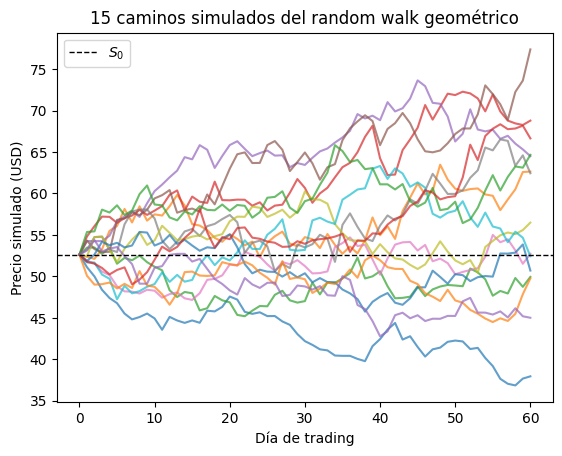

In [4]:
# Visualización con m = 15 y T = 60
caminos_demo = S(S_0=S_0, mu=0.5, sigma=0.35, delta=delta, T=60, m=15)

plt.plot(caminos_demo.T, alpha=0.7)
plt.axhline(S_0, color='black', linestyle='--', linewidth=1, label='$S_0$')
plt.xlabel('Día de trading')
plt.ylabel('Precio simulado (USD)')
plt.title('15 caminos simulados del random walk geométrico')
plt.legend()
plt.show()

Queremos estimar ahora los valores de $\mu$ y $\sigma$ en base a los datos históricos de la acción de YPF.

Para ello, pensemos que significa $\mu$ y $\sigma$ en el modelo de random walk geométrico y como podemos estimarlos a partir de los datos históricos.

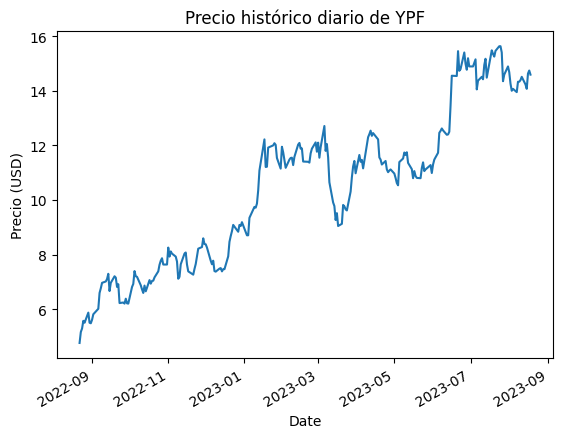

In [5]:
# Datos históricos de YPF
ruta_csv = "YPF one year daily data.csv"

datos = pd.read_csv(ruta_csv)

datos["Date"] = pd.to_datetime(datos["Date"])

# Eliminar símbolos, comas, y convertir a número
datos["Close/Last"] = (
    datos["Close/Last"]
    .astype(str)
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float)
)

datos = datos.sort_values("Date")

ypf = datos.set_index("Date")["Close/Last"].dropna()

ypf.plot()
plt.ylabel("Precio (USD)")
plt.title("Precio histórico diario de YPF")
plt.show()


In [6]:
# Retornos diarios simples
retornos = ypf.pct_change().dropna()

delta = 1 / 252

retorno_medio_diario = retornos.mean()
desvio_diario = retornos.std()

mu_hat = retorno_medio_diario / delta
sigma_hat = desvio_diario / np.sqrt(delta)

print(f"Retorno medio diario:         {retorno_medio_diario:.6f}")
print(f"Drift μ anual:                {mu_hat:.6f}")
print(f"Drift μ anual (%):            {mu_hat * 100:.2f}%")

print(f"Desvío estándar diario:       {desvio_diario:.6f}")
print(f"Volatilidad σ anual:          {sigma_hat:.6f}")
print(f"Volatilidad σ anual (%):      {sigma_hat * 100:.2f}%")

Retorno medio diario:         0.005152
Drift μ anual:                1.298206
Drift μ anual (%):            129.82%
Desvío estándar diario:       0.036286
Volatilidad σ anual:          0.576022
Volatilidad σ anual (%):      57.60%


Con el modelo ya calibrado, queremos estimar:

- La media del precio de la acción de YPF en 1 mes
- La varianza del precio de la acción de YPF en 1 mes
- La probabilidad de pérdida en el valor de la acción de YPF en 1 mes

Estimamos estos valores simulando $m = 100,\ 10000,\ 100000$ caminos.



In [7]:
T_mes = 21  # 1 mes de trading

resultados = []
for m in [100, 10000, 100000]:
    caminos = S(S_0=S_0, mu=mu_hat, sigma=sigma_hat, delta=delta, T=T_mes, m=m)
    S_T = caminos[:, -1]  # precio final de cada camino, a los 21 días

    media = S_T.mean()
    varianza = S_T.var()
    prob_perdida = (S_T < S_0 - 3).mean()  #caminos que terminaron por debajo de S_0

    resultados.append({
        'm': m,
        'Media S_T (USD)': media,
        'Varianza S_T': varianza,
        'Desvío S_T (USD)': np.sqrt(varianza),
        'P(pérdida)': prob_perdida,
    })

tabla_resultados = pd.DataFrame(resultados).set_index('m')
tabla_resultados

,Media S_T (USD),Varianza S_T,Desvío S_T (USD),P(pérdida)
m,,,,
100,58.657707,92.530964,9.619302,0.22000
10000,58.509049,95.323307,9.763366,0.17990
100000,58.568831,95.131810,9.753554,0.17864


### Ejercicio 3

Consideremos un modelo con reversión a la media del tipo

$$ S_{i+1} = S_i + \kappa (\theta - S_i) \Delta + \sigma \sqrt{\Delta}\, Z_{i+1} $$

donde $Z$ vale $+1$ o $-1$ en cada paso (con igual probabilidad, es decir, un shock tipo moneda en vez de normal continuo).


**Cómo detectar un cruce:** en cada paso comparamos el signo del precio *antes* y *después* de actualizarlo. Si el signo cambió (pasó de positivo a negativo o viceversa), el camino atravesó el nivel $\theta = 0$ en ese paso.

In [8]:
# COMPLETADO
import numpy as np

Delta = 1/365
S0 = 0
theta = 0
sigma = 0.2

n_years = 5
n_steps = int(n_years / Delta)
n_paths = 100

resultados = {}

for kappa in [0, 10, 100]:

    cruces = []

    for _ in range(n_paths):

        S_actual = S0
        count = 0

        for _ in range(n_steps):

            Z = np.random.choice([-1, 1])  #shock

            S_new = S_actual + kappa * (theta - S_actual) * Delta + sigma * np.sqrt(Delta) * Z

            # Hubo un cruce de theta?
            if (S_actual - theta) * (S_new - theta) < 0:
                count += 1

            S_actual = S_new

        cruces.append(count)

    resultados[kappa] = np.mean(cruces)
    print(kappa, resultados[kappa])

0 30.13
10 170.79
100 569.68


**Interpretación:**

- Con $\kappa = 0$ no hay ninguna fuerza de reversión: es una random walk aritmética ($\pm\sigma\sqrt{\Delta}$), así que se aleja de $\theta$ aleatoriamente.

- A medida que $\kappa$ crece, la fuerza que empuja de vuelta hacia $\theta$ es cada vez más fuerte. 

- Con $\kappa$ muy grande ($\kappa=100$) el proceso queda oscilando alrededor de $\theta$, cruzándolo muchas más veces, la velocidad de reversión domina completamente al ruido.

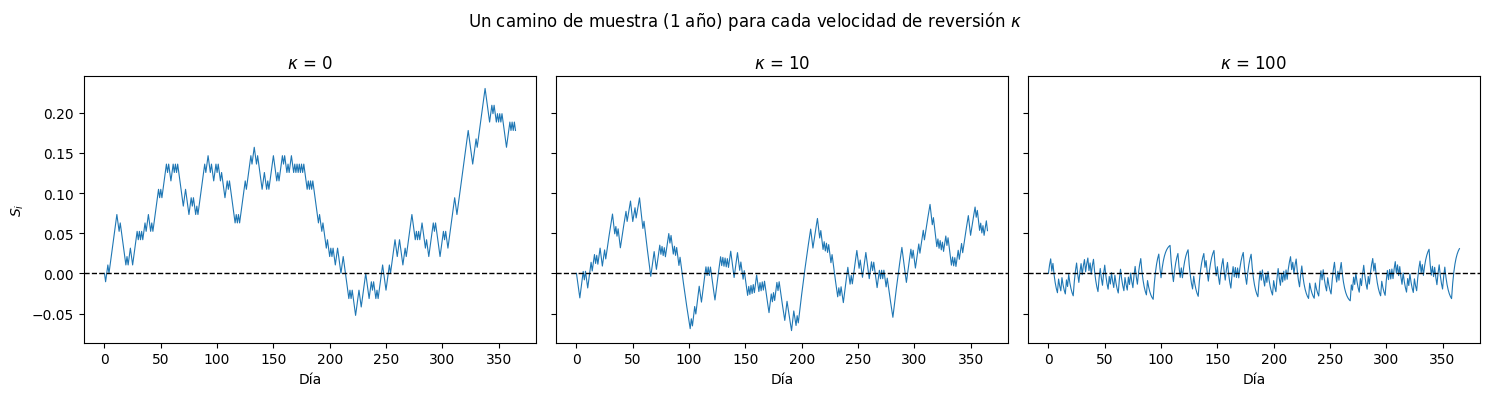

In [9]:
# Visualización para ver el efecto de la reversión a la media
np.random.seed(0)

n_steps_plot = 3650  
n_años_mostrados = 1
n_steps_mostrados = int(n_años_mostrados / Delta)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, kappa in zip(axes, [0, 10, 100]):
    S_actual = S0
    camino = [S_actual]
    for _ in range(n_steps_mostrados):
        Z = np.random.choice([-1, 1])
        S_actual = S_actual + kappa * (theta - S_actual) * Delta + sigma * np.sqrt(Delta) * Z
        camino.append(S_actual)
    ax.plot(camino, linewidth=0.8)
    ax.axhline(theta, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'$\\kappa$ = {kappa}')
    ax.set_xlabel('Día')

axes[0].set_ylabel('$S_i$')
plt.suptitle('Un camino de muestra (1 año) para cada velocidad de reversión $\\kappa$')
plt.tight_layout()
plt.show()